# Strain-Dimension Exploration

This notebook computes the effective dimension $D_{\mathrm{eff}}$ along actuation strain for trained elastic networks.

- Local = allosteric targeted data under `data/allosteric_nets/geometry_targeted/`
- Global = auxetic targeted data under `data/auxetic_nets/targeted_results_sqr/`

The implementation stays thin and reuses the repository's analysis/base modules wherever possible.

In [21]:
import sys
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)
plt.style.use('seaborn-v0_8-whitegrid')

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'analysis').exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from base.config import BOUNDARY_MARGIN, FORCE_TYPE, FORCE_TOL
from base.elastic_network import ElasticNetwork
from base.network_utils import get_square_boundary_nodes
from analysis.cost_utils import compute_trajectory
from analysis.data_io import load_auxetic_network
from analysis.hessian import compute_hessian_spectrum
from analysis.mechanics import bond_strains
from analysis.trajectory import compute_allosteric_trajectory
from training.src.training_functions import crf as _crf

print('Repo root:', REPO_ROOT)
print('JAX devices:', jax.devices())

Repo root: /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets
JAX devices: [CpuDevice(id=0)]


In [22]:
LOCAL_ROOT_TARGETED = REPO_ROOT / 'data' / 'allosteric_nets' / 'geometry_targeted'
GLOBAL_ROOT_TARGETED = REPO_ROOT / 'data' / 'auxetic_nets' / 'targeted_results_sqr'

LOCAL_GEOMETRY_ROOT = REPO_ROOT / 'data' / 'allosteric_nets' / 'geometry'
LOCAL_ROOT = LOCAL_ROOT_TARGETED
GLOBAL_ROOT = REPO_ROOT / 'data' / 'auxetic_nets' / 'results'

FIGURE_DIR = REPO_ROOT / 'figure_data' / 'exploration'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CASE_CACHE_DIR = FIGURE_DIR / 'case_cache'
CASE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
FORCE_RECOMPUTE_CASES = False
LOSS_BEST_TO_INITIAL_THRESHOLD = 1e-4

REPRESENTATIVE_CASES = {
    'local': {'task_id': 3, 'real_id': 0},
    'global': {'task_id': 13, 'real_id': 0},
}

TASK_GROUPS = {
    'local': sorted(p for p in LOCAL_ROOT_TARGETED.glob('task_*') if p.is_dir()),
    'global': sorted(p for p in GLOBAL_ROOT_TARGETED.glob('task_*') if p.is_dir()),
}


def _list_realizations(task_dir):
    return sorted(p for p in task_dir.glob('realization_*') if p.is_dir())


def _incidence_to_edges(incidence_matrix):
    m = np.asarray(incidence_matrix)
    return np.stack([np.argmax(m > 0, axis=1), np.argmax(m < 0, axis=1)], axis=1)


def _safe_best_index(loss_values):
    loss_values = np.asarray(loss_values, dtype=float)
    if loss_values.size == 0:
        return 0
    return int(np.nanargmin(loss_values))


print('Local tasks:', [p.name for p in TASK_GROUPS['local']])
print('Global tasks:', [p.name for p in TASK_GROUPS['global']])

Local tasks: ['task_0', 'task_1', 'task_2', 'task_3', 'task_4']
Global tasks: ['task_00', 'task_01', 'task_02', 'task_03', 'task_04', 'task_05', 'task_06', 'task_07', 'task_08', 'task_09', 'task_10', 'task_11', 'task_12', 'task_13', 'task_16', 'task_17', 'task_18', 'task_19', 'task_20', 'task_21', 'task_22', 'task_23']


In [23]:
def compute_deff_from_spectrum(eigenvalues, tol=1e-12):
    spectrum = np.asarray(eigenvalues, dtype=float)
    usable = spectrum[np.abs(spectrum) > tol]
    if usable.size == 0:
        return np.nan
    inv2 = np.sum(np.abs(usable) ** -2)
    inv4 = np.sum(np.abs(usable) ** -4)
    if not np.isfinite(inv2) or not np.isfinite(inv4) or inv4 <= 0:
        return np.nan
    return float((inv2 ** 2) / (3.0 * inv4))


def _sample_unit_sphere(n_vectors, dimension, rng):
    samples = rng.standard_normal((n_vectors, dimension))
    norms = np.linalg.norm(samples, axis=1, keepdims=True)
    norms = np.where(norms > 0, norms, 1.0)
    return samples / norms


def compute_deff_from_random_forces(Hff, eigenvalues, mode_vectors, n_forces=1000, tol=1e-12, rng_seed=0):
    eigenvalues = np.asarray(eigenvalues, dtype=float)
    mode_vectors = np.asarray(mode_vectors, dtype=float)
    usable = np.abs(eigenvalues) > tol
    assert usable.all(), "All eigenvalues must be above the tolerance threshold."

    eigenvalues = eigenvalues[usable]
    mode_vectors = mode_vectors[:, usable]
    if eigenvalues.size == 0 or mode_vectors.size == 0:
        return np.nan

    rng = np.random.default_rng(rng_seed)
    forces = _sample_unit_sphere(n_forces, mode_vectors.shape[0], rng).T  # (n_dof, M)
    displacements = np.linalg.solve(Hff, forces)  # (n_dof, M)
    projections = np.einsum('ij,jk->ik', mode_vectors.T, displacements)  # (n_modes, M)
    denom = np.sum(projections ** 4, axis=0)
    valid = denom > 0
    if not np.any(valid):
        return np.nan
    numer = np.sum(projections ** 2, axis=0) ** 2
    return float(np.mean(numer[valid])/np.mean(denom[valid]))
    # d_m = numer[valid] / denom[valid]
    # return float(np.mean(d_m))
    


def _sibling_realization_dirs(task_parent, own_dir):
    if not task_parent.is_dir():
        return
    yield own_dir
    for rd in sorted(task_parent.iterdir()):
        if rd.is_dir() and rd != own_dir:
            yield rd


def _resolve_local_task_dir(data_dir, task_id, real_id, geometry_name=None):
    if geometry_name is not None:
        candidate = data_dir / geometry_name / f'task_{task_id}' / f'realization_{real_id}'
        if candidate.exists():
            return candidate
        raise FileNotFoundError(f'No local task directory for geometry={geometry_name}, task={task_id}, realization={real_id}')

    direct = data_dir / f'task_{task_id}' / f'realization_{real_id}'
    if direct.exists():
        return direct

    for geometry_dir in sorted(p for p in data_dir.glob('geometry_*') if p.is_dir()):
        candidate = geometry_dir / f'task_{task_id}' / f'realization_{real_id}'
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f'No local task directory for task={task_id}, realization={real_id} under {data_dir}')


def load_global_network(task_seed, real_seed, data_dir, task_config=None):
    task_parent = data_dir / f'task_{task_seed:02d}'
    own = task_parent / f'realization_{real_seed:02d}'
    with open(own / 'final_network.pkl', 'rb') as fh:
        net = pickle.load(fh)
    stiffnesses = np.array(net['stiffnesses'], dtype=float)
    positions = np.array(net['positions'], dtype=float) if net.get('positions') is not None else None
    edges = np.array(net['edges'], dtype=int) if net.get('edges') is not None else None
    rest_lengths = np.array(net['rest_lengths'], dtype=float) if net.get('rest_lengths') is not None else None
    if positions is None or edges is None:
        for rd in _sibling_realization_dirs(task_parent, own):
            try:
                with open(rd / 'final_network.pkl', 'rb') as fh:
                    alt = pickle.load(fh)
                if positions is None and alt.get('positions') is not None:
                    positions = np.array(alt['positions'], dtype=float)
                if edges is None and alt.get('edges') is not None:
                    edges = np.array(alt['edges'], dtype=int)
                if rest_lengths is None and alt.get('rest_lengths') is not None:
                    rest_lengths = np.array(alt['rest_lengths'], dtype=float)
                if positions is not None and edges is not None:
                    break
            except (FileNotFoundError, KeyError):
                continue
    if positions is None:
        raise RuntimeError(f'No positions for global task {task_seed}')
    if edges is None:
        raise RuntimeError(f'No edges for global task {task_seed}')
    if rest_lengths is None:
        d = positions[edges[:, 0]] - positions[edges[:, 1]]
        rest_lengths = np.linalg.norm(d, axis=1)
    top, bottom, left, right = get_square_boundary_nodes(positions, BOUNDARY_MARGIN)
    boundary = dict(top=top, bottom=bottom, left=left, right=right)
    config = task_config
    if config is None:
        for rd in _sibling_realization_dirs(task_parent, own):
            cfg_path = rd / 'task_config.json'
            if cfg_path.exists():
                with open(cfg_path) as fh:
                    config = json.load(fh)
                if config:
                    break
    if config is None:
        raise RuntimeError(f'No task_config.json for global task {task_seed}')
    network = ElasticNetwork(positions, edges, rest_lengths, stiffnesses)
    return network, boundary, config


def load_global_stiffness_trajectory(task_id, real_id, data_dir):
    """Load (T, E) stiffness trajectory and (T,) loss for a global task."""
    d = data_dir / f'task_{task_id:02d}' / f'realization_{real_id:02d}'
    k_traj = np.load(d / 'stiffness_trajectory.npy')
    loss_traj = np.load(d / 'loss_trajectory.npy')
    return k_traj, loss_traj


def load_global_case(task_id, real_id, data_dir):
    network, boundary, task_config = load_global_network(task_id, real_id, data_dir)
    stiffness_history, loss_history = load_global_stiffness_trajectory(task_id, real_id, data_dir)
    initial_loss = float(loss_history[0])
    best_idx = _safe_best_index(loss_history)
    best_loss = float(loss_history[best_idx])
    if not np.isfinite(initial_loss) or initial_loss <= 0:
        return None
    if best_loss / initial_loss >= LOSS_BEST_TO_INITIAL_THRESHOLD:
        print(f'Skipping global case (task_id={task_id}, real_id={real_id}): best/initial={best_loss / initial_loss:.3e}')
        return None
    return {
        'family': 'global',
        'task_id': task_id,
        'real_id': real_id,
        'network': network,
        'boundary': boundary,
        'initial_stiffness': stiffness_history[0],
        'best_stiffness': stiffness_history[best_idx],
        'loss_history': loss_history,
        'initial_loss': initial_loss,
        'best_loss': best_loss,
        'loss_ratio': best_loss / initial_loss,
        'stiffness_history': stiffness_history,
        'compression_strains': [float(s) for s in task_config['compression_strains']],
        'target_poisson_ratios': [float(r) for r in task_config['target_poisson_ratios']],
        'compression_strain': float(abs(task_config['compression_strains'][0])),
        'n_steps': 200,
        'rest_lengths': np.asarray(network.rest_lengths),
        'edges': np.asarray(network.edges, dtype=int),
    }


def load_local_case(task_id, real_id, data_dir, geometry_name=None):
    task_dir = _resolve_local_task_dir(data_dir, task_id, real_id, geometry_name=geometry_name)

    traj_path = task_dir / 'stiffnesses_traj.npy'
    steps_path = task_dir / 'stiffnesses_traj_steps.npy'
    mse1_path = task_dir / 'mse1.npy'
    mse2_path = task_dir / 'mse2.npy'
    if not (traj_path.exists() and steps_path.exists() and mse1_path.exists() and mse2_path.exists()):
        raise FileNotFoundError(f"Missing required files for task {task_id}, realization {real_id}")

    traj = np.load(traj_path)               # (T_ckpt, E)
    if traj.ndim == 1:
        traj = traj[None, :]
    steps = np.load(steps_path).astype(int)  # (T_ckpt,) 1-indexed step numbers
    loss_full = np.load(mse1_path) + np.load(mse2_path)
    idx = np.clip(steps - 1, 0, len(loss_full) - 1)
    loss = loss_full[idx]
    initial_loss = float(loss[0])
    best_idx = int(np.nanargmin(loss))
    best_loss = float(loss[best_idx])
    if not np.isfinite(initial_loss) or initial_loss <= 0:
        return None
    if best_loss / initial_loss >= LOSS_BEST_TO_INITIAL_THRESHOLD:
        print(f'Skipping local case (task_id={task_id}, real_id={real_id}): best/initial={best_loss / initial_loss:.3e}')
        return None

    nodes = np.load(task_dir / 'nodes.npy')
    incidence_matrix = np.load(task_dir / 'incidence_matrix.npy')
    edges = _incidence_to_edges(incidence_matrix)
    eq_lengths = np.load(task_dir / 'eq_lengths.npy')
    task_values = np.loadtxt(task_dir / 'tasks.txt')
    return {
        'family': 'local',
        'task_id': task_id,
        'real_id': real_id,
        'geometry': geometry_name,
        'nodes': nodes,
        'edges': edges,
        'eq_lengths': eq_lengths,
        'initial_stiffness': traj[0],
        'best_stiffness': traj[best_idx],
        'initial_loss': initial_loss,
        'best_loss': best_loss,
        'loss_ratio': best_loss / initial_loss,
        'stiffness_history': traj,
        'task_values': task_values,
        'input_strain': 1.0,
        'n_steps': 100,
        'constrained_nodes': np.array([0, 1], dtype=int),
    }


def compute_local_trajectory(stiffnesses, nodes0, edges, eq_lengths, input_strain, n_steps=100):
    positions_flat = jnp.asarray(np.asarray(nodes0, dtype=float).ravel())
    edges_jax = jnp.asarray(np.asarray(edges, dtype=np.int32))
    eq_lengths_jax = jnp.asarray(np.asarray(eq_lengths, dtype=float))
    stiffnesses_jax = jnp.asarray(np.asarray(stiffnesses, dtype=float))
    source_dof = jnp.array([0, 2, 1, 3], dtype=jnp.int32)

    x0, y0 = map(float, nodes0[0])
    x1_init, y1_init = map(float, nodes0[1])
    input_distance = float(np.linalg.norm(nodes0[1] - nodes0[0]))

    traj = [np.asarray(nodes0, dtype=float)]
    current = positions_flat
    for step in range(1, n_steps):
        frac = step / (n_steps - 1)
        x1_target = x1_init + frac * input_strain * input_distance
        imposed = jnp.array([x0, x1_target, y0, y1_init], dtype=jnp.float64)
        current = _crf(stiffnesses_jax, edges_jax, eq_lengths_jax, current, source_dof, imposed)
        traj.append(np.asarray(current, dtype=float).reshape(-1, 2))
    return traj


def compute_case_curve(case, stiffnesses, n_force_samples=1000, rng_seed=0):
    if case['family'] == 'global':
        trajectory = compute_trajectory(
            stiffnesses,
            case['network'],
            case['boundary'],
            compression_strain=-case['compression_strain'],
            n_steps=case['n_steps'],
            force_type=FORCE_TYPE,
            tol=FORCE_TOL,
        )
        constrained_nodes = np.unique(np.concatenate([case['boundary']['top'], case['boundary']['bottom']]))
        strain_axis = np.linspace(0.0, case['compression_strain'], len(trajectory))
        edges = case['edges']
        rest_lengths = case['rest_lengths']
    else:
        trajectory = compute_local_trajectory(
            stiffnesses,
            case['nodes'],
            case['edges'],
            case['eq_lengths'],
            input_strain=case['input_strain'],
            n_steps=case['n_steps'],
        )
        constrained_nodes = case['constrained_nodes']
        strain_axis = np.linspace(0.0, case['input_strain'], len(trajectory))
        edges = case['edges']
        rest_lengths = case['eq_lengths']

    deff_values = []
    for positions in trajectory:
        eigenvalues, eigenvectors, H_ff = compute_hessian_spectrum(
            positions,
            edges,
            stiffnesses,
            rest_lengths,
            constrained_nodes=constrained_nodes,
        )

        deff_values.append(
            compute_deff_from_random_forces(
                H_ff,
                eigenvalues,
                eigenvectors,
                n_forces=n_force_samples,
                rng_seed=rng_seed,
            )
        )

    return strain_axis, np.asarray(deff_values, dtype=float), trajectory

## Sample Input Data

Load one representative local task and one representative global task before running the full ensemble sweep.

In [24]:
local_rep = load_local_case(REPRESENTATIVE_CASES['local']['task_id'], REPRESENTATIVE_CASES['local']['real_id'], LOCAL_ROOT_TARGETED)


print('Local case:')
print('  task / realization:', local_rep['task_id'], local_rep['real_id'])
print('  nodes / edges:', local_rep['nodes'].shape[0], local_rep['edges'].shape[0])
print('  stiffness history:', local_rep['stiffness_history'].shape)
print('  local trajectory strain target:', local_rep['input_strain'])

global_rep = load_global_case(REPRESENTATIVE_CASES['global']['task_id'], REPRESENTATIVE_CASES['global']['real_id'], GLOBAL_ROOT_TARGETED)

print('Global case:')
print('  task / realization:', global_rep['task_id'], global_rep['real_id'])
print('  nodes / edges:', global_rep['network'].positions.shape[0], global_rep['network'].edges.shape[0])
print('  stiffness history:', global_rep['stiffness_history'].shape)
print('  compression strain magnitude:', global_rep['compression_strain'])
print('  trajectory steps:', global_rep['n_steps'])

assert local_rep['nodes'].shape[0] > 0
assert global_rep['network'].positions.shape[0] > 0
assert local_rep['initial_stiffness'].shape == local_rep['best_stiffness'].shape
assert global_rep['initial_stiffness'].shape == global_rep['best_stiffness'].shape

Local case:
  task / realization: 3 0
  nodes / edges: 87 253
  stiffness history: (18, 253)
  local trajectory strain target: 1.0
Global case:
  task / realization: 13 0
  nodes / edges: 98 194
  stiffness history: (5000, 194)
  compression strain magnitude: 0.3
  trajectory steps: 200


## Run Initial Tests

Evaluate the representative examples with initial and best-trained stiffness vectors, then confirm the outputs are finite.

In [25]:
# local_initial_strain, local_initial_deff, local_initial_traj = compute_case_curve(
#     local_rep,
#     local_rep['initial_stiffness'],
# )
# local_best_strain, local_best_deff, local_best_traj = compute_case_curve(
#     local_rep,
#     local_rep['best_stiffness'],
# )

# global_initial_strain, global_initial_deff, global_initial_traj = compute_case_curve(
#     global_rep,
#     global_rep['initial_stiffness'],
# )
# global_best_strain, global_best_deff, global_best_traj = compute_case_curve(
#     global_rep,
#     global_rep['best_stiffness'],
# )

# print('Local D_eff range (initial):', np.nanmin(local_initial_deff), np.nanmax(local_initial_deff))
# print('Local D_eff range (best):   ', np.nanmin(local_best_deff), np.nanmax(local_best_deff))
# print('Global D_eff range (initial):', np.nanmin(global_initial_deff), np.nanmax(global_initial_deff))
# print('Global D_eff range (best):   ', np.nanmin(global_best_deff), np.nanmax(global_best_deff))

# assert np.isfinite(local_initial_deff).any()
# assert np.isfinite(local_best_deff).any()
# assert np.isfinite(global_initial_deff).any()
# assert np.isfinite(global_best_deff).any()

## Execute First End-to-End Workflow

Plot $D_{\mathrm{eff}}$ versus imposed strain for the representative local and global tasks, before and after training.

In [26]:
# representative_curves = {
#     'local': {
#         'initial': (local_initial_strain, local_initial_deff),
#         'best': (local_best_strain, local_best_deff),
#     },
#     'global': {
#         'initial': (global_initial_strain, global_initial_deff),
#         'best': (global_best_strain, global_best_deff),
#     },
# }

# fig, axes = plt.subplots(1, 2, figsize=(12, 4),constrained_layout=True)
# for ax, family in zip(axes, ['local', 'global']):
#     strain_initial, deff_initial = representative_curves[family]['initial']
#     strain_best, deff_best = representative_curves[family]['best']
#     ax.plot(strain_initial, deff_initial, label='before training', lw=2.2)
#     ax.plot(strain_best, deff_best, label='after training', lw=2.2)
#     ax.set_title(f'{family.title()} representative case')
#     ax.set_xlabel('Imposed strain magnitude')
#     # ax.set_yscale('log')
#     ax.grid(True, alpha=0.3)
# axes[0].set_ylim([1,1.5])
# axes[0].set_ylim([1,1.5])
# axes[0].set_ylabel(r'$D_{\mathrm{eff}}$')
# axes[1].legend(frameon=False, loc='best')
# fig.suptitle(r'Effective dimension along actuation strain: representative cases')
# fig.savefig(FIGURE_DIR / 'deff_representative_cases.svg', bbox_inches='tight')
# plt.show()

# print('Representative workflow complete.')
# print('  local points:', len(local_initial_strain), len(local_best_strain))
# print('  global points:', len(global_initial_strain), len(global_best_strain))
# print('  saved figure:', FIGURE_DIR / 'deff_representative_cases.svg')

## Zero-Strain Full Hessian Check

Compute $D_{\mathrm{eff}}$ at zero strain using the full Hessian without removing input-node rows or columns.

In [27]:
# def compute_zero_strain_deff(case, stiffnesses, constrained_nodes=None, n_force_samples=200, rng_seed=0):
#     if case['family'] == 'global':
#         positions = np.asarray(case['network'].positions, dtype=float)
#         edges = np.asarray(case['edges'], dtype=int)
#         rest_lengths = np.asarray(case['rest_lengths'], dtype=float)
#     else:
#         positions = np.asarray(case['nodes'], dtype=float)
#         edges = np.asarray(case['edges'], dtype=int)
#         rest_lengths = np.asarray(case['eq_lengths'], dtype=float)

#     eigenvalues, eigenvectors = compute_hessian_spectrum(
#         positions,
#         edges,
#         stiffnesses,
#         rest_lengths,
#         constrained_nodes=constrained_nodes,
#     )
#     if constrained_nodes is None or len(np.asarray(constrained_nodes).ravel()) == 0:
#         free_dofs = np.arange(positions.size)
#     else:
#         constrained_dofs = np.concatenate([
#             np.asarray(constrained_nodes, dtype=int) * 2,
#             np.asarray(constrained_nodes, dtype=int) * 2 + 1,
#         ])
#         free_dofs = np.setdiff1d(np.arange(positions.size), np.unique(constrained_dofs))
#     free_vectors = eigenvectors[free_dofs, :]
#     return compute_deff_from_random_forces(
#         eigenvalues,
#         free_vectors,
#         n_forces=n_force_samples,
#         rng_seed=rng_seed,
#     )


# zero_strain_comparison_rows = []
# for family_name, case in [('local', local_rep), ('global', global_rep)]:
#     if family_name == 'local':
#         constrained_nodes = case['constrained_nodes']
#     else:
#         constrained_nodes = np.unique(np.concatenate([case['boundary']['top'], case['boundary']['bottom']]))

#     for state in ['initial', 'best']:
#         stiffnesses = case[f'{state}_stiffness']
#         deff_full = compute_zero_strain_deff(case, stiffnesses, constrained_nodes=None)
#         deff_constrained = compute_zero_strain_deff(case, stiffnesses, constrained_nodes=constrained_nodes)
#         zero_strain_comparison_rows.append({
#             'family': family_name,
#             'state': state,
#             'D_eff_zero_full': deff_full,
#             'D_eff_zero_constrained': deff_constrained,
#             'ratio_full_to_constrained': deff_full / deff_constrained if np.isfinite(deff_full) and np.isfinite(deff_constrained) and deff_constrained != 0 else np.nan,
#         })

# zero_strain_comparison = pd.DataFrame(zero_strain_comparison_rows)
# display(zero_strain_comparison)

# fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, constrained_layout=True)
# for ax, family_name in zip(axes, ['local', 'global']):
#     subset = zero_strain_comparison[zero_strain_comparison['family'] == family_name].set_index('state')
#     x = np.arange(len(subset.index))
#     width = 0.35
#     ax.bar(x - width / 2, subset['D_eff_zero_full'], width, label='full Hessian')
#     ax.bar(x + width / 2, subset['D_eff_zero_constrained'], width, label='input-constrained')
#     ax.set_xticks(x)
#     ax.set_xticklabels(subset.index.tolist())
#     ax.set_title(f'{family_name.title()} zero-strain comparison')
#     ax.set_ylabel(r'$D_{\mathrm{eff}}$')
#     ax.grid(True, axis='y', alpha=0.3)
# axes[1].legend(frameon=False, loc='best')
# fig.suptitle(r'Zero-strain $D_{\mathrm{eff}}$: full Hessian vs input-constrained Hessian')
# fig.savefig(FIGURE_DIR / 'deff_zero_strain_comparison.svg', bbox_inches='tight')
# plt.show()

# print('Saved comparison figure to', FIGURE_DIR / 'deff_zero_strain_comparison.svg')

## Actuation GIF

Save a two-panel GIF showing the local and global actuation trajectories frame by frame before the ensemble sweep.

In [28]:
# import matplotlib.animation as animation
# from matplotlib.collections import LineCollection
# from IPython.display import Image, display

# def _resample_trajectory(traj, n_frames):
#     traj = np.asarray(traj, dtype=float)
#     if traj.shape[0] == n_frames:
#         return traj
#     t_old = np.linspace(0.0, 1.0, traj.shape[0])
#     t_new = np.linspace(0.0, 1.0, n_frames)
#     flat = traj.reshape(traj.shape[0], -1)
#     flat_new = np.vstack([np.interp(t_new, t_old, flat[:, idx]) for idx in range(flat.shape[1])]).T
#     return flat_new.reshape(n_frames, *traj.shape[1:])

# def _draw_network(ax, positions, edges, title, constrained_nodes=None, boundary_nodes=None):
#     ax.clear()
#     segments = [positions[edge] for edge in edges]
#     lc = LineCollection(segments, colors='0.25', linewidths=1.1, alpha=0.85)
#     ax.add_collection(lc)
#     ax.scatter(positions[:, 0], positions[:, 1], s=10, c='black', zorder=3)
#     if constrained_nodes is not None and len(constrained_nodes) > 0:
#         ax.scatter(positions[constrained_nodes, 0], positions[constrained_nodes, 1], s=22, c='crimson', zorder=4)
#     if boundary_nodes is not None and len(boundary_nodes) > 0:
#         ax.scatter(positions[boundary_nodes, 0], positions[boundary_nodes, 1], s=14, c='tab:blue', zorder=4)
#     pad_x = 0.05 * (positions[:, 0].max() - positions[:, 0].min() + 1e-12)
#     pad_y = 0.05 * (positions[:, 1].max() - positions[:, 1].min() + 1e-12)
#     ax.set_xlim(positions[:, 0].min() - pad_x, positions[:, 0].max() + pad_x)
#     ax.set_ylim(positions[:, 1].min() - pad_y, positions[:, 1].max() + pad_y)
#     ax.set_aspect('equal')
#     ax.set_title(title)
#     ax.set_xticks([])
#     ax.set_yticks([])

# local_anim_traj = _resample_trajectory(local_best_traj, 120)
# global_anim_traj = _resample_trajectory(global_best_traj, 120)
# n_frames = min(len(local_anim_traj), len(global_anim_traj))
# local_anim_traj = local_anim_traj[:n_frames]
# global_anim_traj = global_anim_traj[:n_frames]

# gif_path = FIGURE_DIR / 'actuation_dual_panel.gif'
# fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# def update(frame_idx):
#     _draw_network(
#         axes[0],
#         local_anim_traj[frame_idx],
#         local_rep['edges'],
#         f'Local actuation frame {frame_idx + 1}/{n_frames}',
#         constrained_nodes=local_rep['constrained_nodes'],
#     )
#     _draw_network(
#         axes[1],
#         global_anim_traj[frame_idx],
#         global_rep['edges'],
#         f'Global actuation frame {frame_idx + 1}/{n_frames}',
#         boundary_nodes=np.unique(np.concatenate([global_rep['boundary']['top'], global_rep['boundary']['bottom']])),
#     )
#     fig.suptitle('Representative actuation trajectories', y=1.02)
#     return axes

# anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=80, blit=False)
# anim.save(gif_path, writer=animation.PillowWriter(fps=12))
# plt.close(fig)
# display(Image(filename=str(gif_path)))
# print('Saved GIF to', gif_path)

## Ensemble Sweep

Discover all available trained tasks in the targeted local and global data roots, evaluate the same $D_{\mathrm{eff}}$ pipeline, and build a compact ensemble summary.

In [35]:
from tqdm import tqdm
import IPython


def _case_cache_path(family, root_tag, task_id, real_id, geometry_name=None):
    parts = [family, root_tag]
    if geometry_name is not None:
        parts.append(geometry_name)
    parts += [f'task_{task_id:02d}', f'realization_{real_id:02d}']
    return CASE_CACHE_DIR / ('_'.join(parts) + '.pkl')


def discover_cases(root, family, only_cache=False, which_tasks=None):
    cases = []
    geometry_dirs = sorted(p for p in root.glob('geometry_*') if p.is_dir())
    task_roots = [(g.name, g) for g in geometry_dirs] if geometry_dirs else [(None, root)]

    for geometry_name, task_parent in task_roots:
        for task_dir in sorted(p for p in task_parent.glob('task_*') if p.is_dir()):
            task_id = int(task_dir.name.split('_')[1])
            if which_tasks is not None and task_id not in which_tasks:
                continue

            for real_dir in _list_realizations(task_dir):
                real_id = int(real_dir.name.split('_')[1])
                cache_path = _case_cache_path(family, root.name, task_id, real_id, geometry_name=geometry_name)
                if cache_path.exists() and not FORCE_RECOMPUTE_CASES:
                    with open(cache_path, 'rb') as fh:
                        cached_case = pickle.load(fh)
                    if cached_case is not None:
                        cases.append(cached_case)
                    continue

                if only_cache:
                    continue

                print(f'Loading case (family={family}, task_id={task_id}, real_id={real_id}), geometry={geometry_name} ...')

                if family == 'local':
                    try:
                        case = load_local_case(task_id, real_id, data_dir=root, geometry_name=geometry_name)
                    except Exception as e:
                        print(f'Error loading local case (task_id={task_id}, real_id={real_id}): {e}')
                        continue
                else:
                    # try:
                    case = load_global_case(task_id, real_id, data_dir=root)
                    # except Exception as e:
                    # print(f'Error loading global case (task_id={task_id}, real_id={real_id}): {e}')
                if case is None:
                    continue
                with open(cache_path, 'wb') as fh:
                    pickle.dump(case, fh)
                cases.append(case)

                IPython.display.clear_output(wait=True)
                print(f'Discovered {len(cases)} cases so far...')
    return cases


def _resample_curve(strain, values, grid):
    strain = np.asarray(strain, dtype=float)
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(strain) & np.isfinite(values)
    if valid.sum() < 2:
        return np.full_like(grid, np.nan, dtype=float)
    strain = strain[valid]
    values = values[valid]
    order = np.argsort(strain)
    strain = strain[order]
    values = values[order]
    if strain[-1] <= 0:
        return np.full_like(grid, np.nan, dtype=float)
    return np.interp(grid, strain / strain[-1], values, left=np.nan, right=np.nan)


ensemble_cases = {}
print('Discovering all local cases...')
ensemble_cases['local'] = discover_cases(LOCAL_ROOT, 'local', only_cache=False)
print('  local :', len(ensemble_cases['local']))

print('Discovering all global cases...', flush=True)
ensemble_cases['global'] = discover_cases(GLOBAL_ROOT, 'global', only_cache=False)
print('  global:', len(ensemble_cases['global']))

Discovering all local cases...
Loading case (family=local, task_id=0, real_id=4), geometry=None ...
Skipping local case (task_id=0, real_id=4): best/initial=4.013e-03
Loading case (family=local, task_id=2, real_id=3), geometry=None ...
Skipping local case (task_id=2, real_id=3): best/initial=8.141e-03
Loading case (family=local, task_id=2, real_id=4), geometry=None ...
Skipping local case (task_id=2, real_id=4): best/initial=1.536e-02
Loading case (family=local, task_id=3, real_id=1), geometry=None ...
Skipping local case (task_id=3, real_id=1): best/initial=1.478e-03
Loading case (family=local, task_id=3, real_id=3), geometry=None ...
Skipping local case (task_id=3, real_id=3): best/initial=8.388e-04
Loading case (family=local, task_id=4, real_id=2), geometry=None ...
Skipping local case (task_id=4, real_id=2): best/initial=2.575e-03
  local : 19
Discovering all global cases...
Loading case (family=global, task_id=2, real_id=15), geometry=None ...
Skipping global case (task_id=2, real

In [36]:
ensemble_records = []
ensemble_curves = {'local': {'initial': [], 'best': []}, 'global': {'initial': [], 'best': []}}
ensemble_grid = np.linspace(0.0, 1.0, 101)

for family, cases in ensemble_cases.items():
    for case in tqdm(cases):
        for state in ['initial', 'best']:
            strain_axis, deff_values, _ = compute_case_curve(case, case[f'{state}_stiffness'])
            ensemble_records.append({
                'family': family,
                'task_id': case['task_id'],
                'real_id': case['real_id'],
                'state': state,
                'strain_min': float(np.nanmin(strain_axis)),
                'strain_max': float(np.nanmax(strain_axis)),
                'deff_min': float(np.nanmin(deff_values)),
                'deff_max': float(np.nanmax(deff_values)),
                'deff_curve': deff_values,
                'strain_curve': strain_axis,
            })
            ensemble_curves[family][state].append(_resample_curve(strain_axis, deff_values, ensemble_grid))

ensemble_df = pd.DataFrame(ensemble_records)
print('Ensemble summary rows:', len(ensemble_df))
print(ensemble_df[['family', 'state', 'task_id', 'real_id']].head())


100%|██████████| 264/264 [1:14:45<00:00, 16.99s/it]

Ensemble summary rows: 566
  family    state  task_id  real_id
0  local  initial        0        0
1  local     best        0        0
2  local  initial        0        1
3  local     best        0        1
4  local  initial        0        2


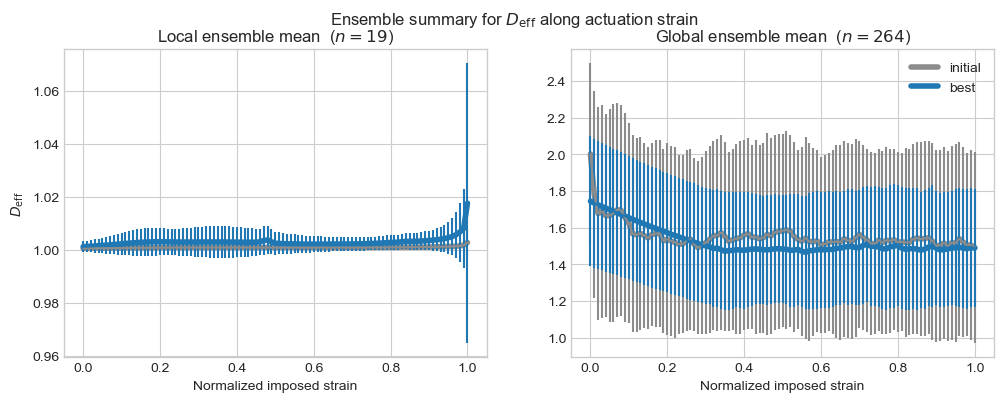

Saved ensemble figure to /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/exploration/deff_ensemble_summary.svg
Saved ensemble metadata to /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/exploration/deff_ensemble_summary.csv
Saved ensemble curves to /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/exploration/deff_ensemble_summary.pkl


In [37]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (ax, family) in enumerate(zip(axes, ['local', 'global'])):
    n_networks = len(ensemble_curves[family]['initial'])
    for state, color in [('initial', '0.55'), ('best', 'C0')]:
        curves = np.asarray(ensemble_curves[family][state], dtype=float)
        if curves.size == 0:
            continue
        mean_curve = np.nanmean(curves, axis=0)
        std_curve = np.nanstd(curves, axis=0)
        ax.plot(ensemble_grid, mean_curve, color=color, lw=4, label=state.replace('_', ' '))
        ax.errorbar(ensemble_grid, mean_curve, yerr=std_curve, color=color)

    ax.set_title(f'{family.title()} ensemble mean  ($n={n_networks}$)')
    ax.set_xlabel('Normalized imposed strain')
axes[0].set_ylabel(r'$D_{\mathrm{eff}}$')
axes[1].legend(frameon=False, loc='best')
fig.suptitle(r'Ensemble summary for $D_{\mathrm{eff}}$ along actuation strain')
fig.savefig(FIGURE_DIR / 'deff_ensemble_summary.svg', bbox_inches='tight')
plt.show()

ensemble_meta = ensemble_df.drop(columns=['deff_curve', 'strain_curve'])
ensemble_meta_output = FIGURE_DIR / 'deff_ensemble_summary.csv'
ensemble_meta.to_csv(ensemble_meta_output, index=False)
ensemble_df.to_pickle(FIGURE_DIR / 'deff_ensemble_summary.pkl')
print('Saved ensemble figure to', FIGURE_DIR / 'deff_ensemble_summary.svg')
print('Saved ensemble metadata to', ensemble_meta_output)
print('Saved ensemble curves to', FIGURE_DIR / 'deff_ensemble_summary.pkl')

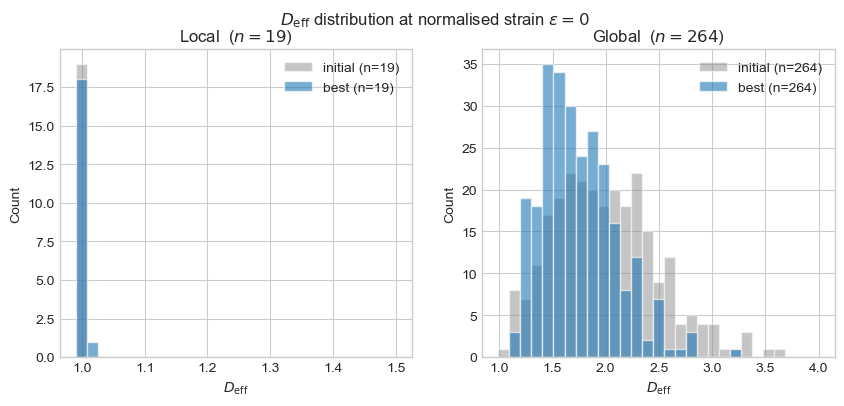

Saved histogram for strain=0 to /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/exploration/deff_hist_strain0.svg


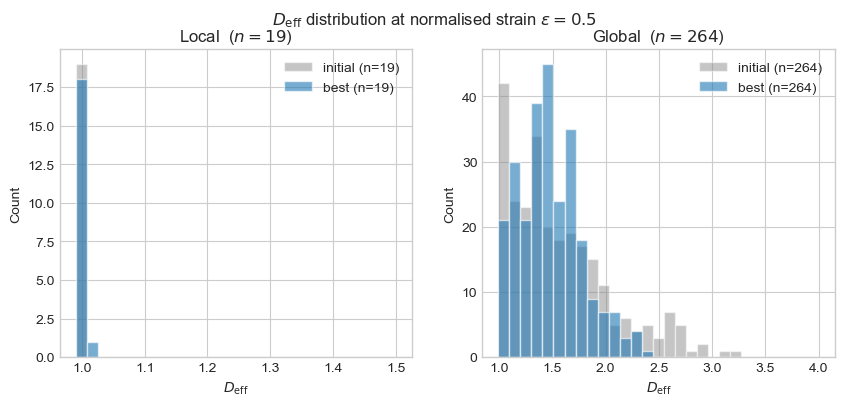

Saved histogram for strain=0.5 to /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/exploration/deff_hist_strain0.5.svg


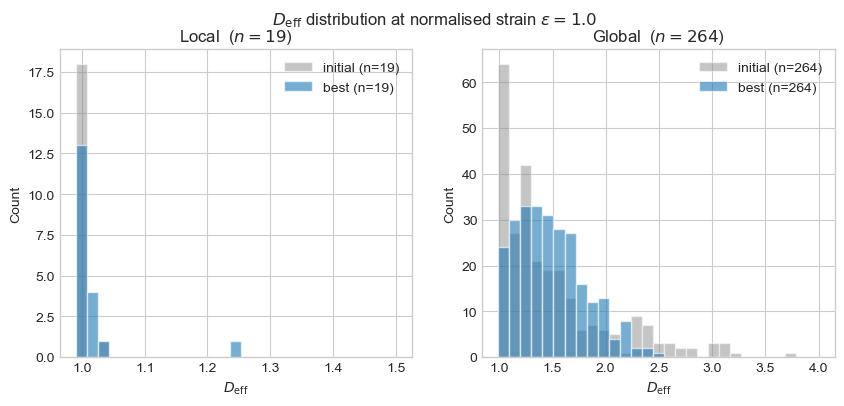

Saved histogram for strain=1.0 to /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/exploration/deff_hist_strain1.0.svg


In [38]:
# D_eff histograms at three normalised strain values: 0, 0.5, 1.0
# ensemble_grid has 101 points over [0, 1], so indices 0, 50, 100.
strain_samples = [(0, 0), (50, 0.5), (100, 1.0)]

for grid_idx, strain_val in strain_samples:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, family in zip(axes, ['local', 'global']):
        for state, color, alpha in [('initial', '0.55', 0.5), ('best', 'C0', 0.6)]:
            curves = np.asarray(ensemble_curves[family][state], dtype=float)
            if curves.size == 0:
                continue
            vals = curves[:, grid_idx]
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                continue
            if family == 'global':
                ax.hist(vals, bins=np.linspace(0.99, 4, 30), color=color, alpha=alpha,
                    label=f'{state.replace("_", " ")} (n={vals.size})', edgecolor='white')
            else:
                ax.hist(vals, bins=np.linspace(0.99, 1.5, 30), color=color, alpha=alpha,
                    label=f'{state.replace("_", " ")} (n={vals.size})', edgecolor='white')
        n_networks = len(ensemble_curves[family]['initial'])
        ax.set_title(f'{family.title()}  ($n={n_networks}$)')
        ax.set_xlabel(r'$D_{\mathrm{eff}}$')
        ax.set_ylabel('Count')
        ax.legend()
    fig.suptitle(rf'$D_{{\mathrm{{eff}}}}$ distribution at normalised strain $\epsilon={strain_val}$')
    fig.savefig(FIGURE_DIR / f'deff_hist_strain{strain_val}.svg', bbox_inches='tight')
    plt.show()
    print(f'Saved histogram for strain={strain_val} to', FIGURE_DIR / f'deff_hist_strain{strain_val}.svg')

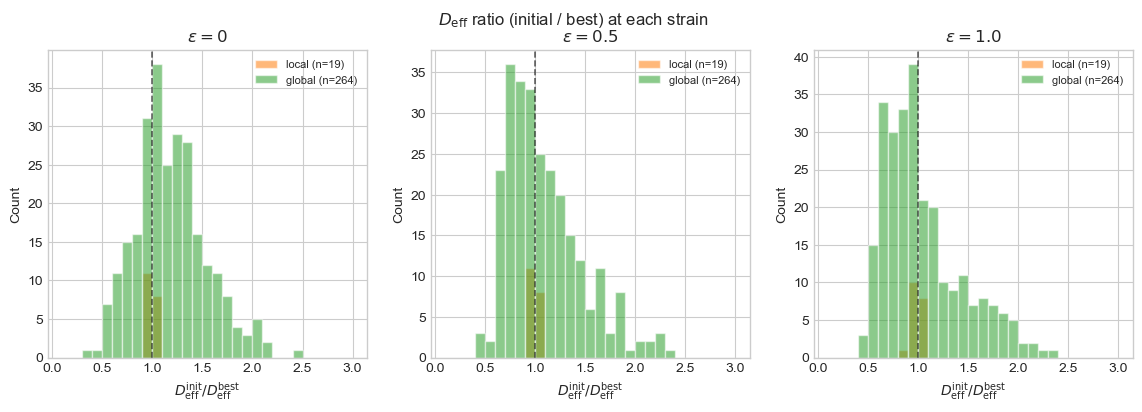

Saved ratio figure to /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/exploration/deff_ratio_distribution.svg


In [39]:
# D_eff(initial) / D_eff(best) ratio distributions at three normalised strains.
# One figure, three subplots (one per epsilon).  Each subplot overlays local and global.
strain_samples = [(0, 0), (50, 0.5), (100, 1.0)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (grid_idx, strain_val) in zip(axes, strain_samples):
    for family, color, alpha in [('local', 'C1', 0.55), ('global', 'C2', 0.55)]:
        initial_curves = np.asarray(ensemble_curves[family]['initial'], dtype=float)
        best_curves    = np.asarray(ensemble_curves[family]['best'],    dtype=float)
        if initial_curves.size == 0 or best_curves.size == 0:
            continue
        init_vals = initial_curves[:, grid_idx]
        best_vals = best_curves[:, grid_idx]
        valid = np.isfinite(init_vals) & np.isfinite(best_vals) & (best_vals != 0)
        ratio = init_vals[valid] / best_vals[valid]
        n = valid.sum()
        ax.hist(ratio, bins=np.linspace(0.1, 3, 30), color=color, alpha=alpha,
                label=f'{family} (n={n})', edgecolor='white')

    ax.axvline(1.0, color='k', lw=1.2, ls='--', alpha=0.6)
    ax.set_title(rf'$\epsilon = {strain_val}$')
    ax.set_xlabel(r'$D_{{\mathrm{{eff}}}}^{{\mathrm{{init}}}} / D_{{\mathrm{{eff}}}}^{{\mathrm{{best}}}}$')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle(r'$D_{\mathrm{eff}}$ ratio (initial / best) at each strain')
fig.savefig(FIGURE_DIR / 'deff_ratio_distribution.svg', bbox_inches='tight')
plt.show()
print('Saved ratio figure to', FIGURE_DIR / 'deff_ratio_distribution.svg')

## Inspect and Save Outputs

The notebook saves the representative and ensemble summary figures to `figure_data/exploration/` and exports the ensemble table as CSV for later reuse.